In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv("C:\\Users\\SUMIT\\OneDrive\\Dokumen\\online_retail.csv")

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2022-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2022-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2022-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2022-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2022-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [3]:
# Dataset Shape

print("Rows and Columns:", df.shape)

Rows and Columns: (541909, 8)


In [4]:
# Dataset Information

df.info()
df.isnull().sum()
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
Duplicate Records: 5268


In [5]:
# Remove Duplicates

df.drop_duplicates(inplace=True)

In [6]:
# Statistical Summary

df.describe()


print("Unique Customers:",
      df['CustomerID'].nunique())

Unique Customers: 4372


In [7]:
# Unique Products

print("Unique Products:",
      df['StockCode'].nunique())

Unique Products: 4070


In [8]:
# Countries Covered

print("Countries:",
      df['Country'].nunique())

Countries: 38


In [9]:
# Top Countries by Transactions

df['Country'].value_counts().head(10)

Country
United Kingdom    490300
Germany             9480
France              8541
EIRE                8184
Spain               2528
Netherlands         2371
Belgium             2069
Switzerland         1994
Portugal            1510
Australia           1258
Name: count, dtype: int64

In [10]:
# Top Purchased Products

df['Description'].value_counts().head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2357
REGENCY CAKESTAND 3 TIER              2189
JUMBO BAG RED RETROSPOT               2156
PARTY BUNTING                         1720
LUNCH BAG RED RETROSPOT               1625
ASSORTED COLOUR BIRD ORNAMENT         1488
SET OF 3 CAKE TINS PANTRY DESIGN      1465
PACK OF 72 RETROSPOT CAKE CASES       1367
LUNCH BAG  BLACK SKULL.               1323
NATURAL SLATE HEART CHALKBOARD        1272
Name: count, dtype: int64

In [11]:
# Data Preprocessing

# 1. Remove Missing Customer IDs

df = df.dropna(subset=['CustomerID'])

# 2. Exclude Cancelled Invoices

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 3. Remove Invalid Quantities

df = df[df['Quantity'] > 0]

# 4. Remove Invalid Prices

df = df[df['UnitPrice'] > 0]

# Convert Data Types

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Complete Preprocessing Code

# Remove missing Customer IDs
df = df.dropna(subset=['CustomerID'])

# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove invalid quantities
df = df[df['Quantity'] > 0]

# Remove invalid prices
df = df[df['UnitPrice'] > 0]

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Reset index
df.reset_index(drop=True, inplace=True)

# Verification Checks

# Dataset Shape After Cleaning
print("Dataset Shape:", df.shape)

# Missing Values Check
print(df.isnull().sum())

# Quantity Validation
print("Minimum Quantity:", df['Quantity'].min())

# Price Validation
print("Minimum Unit Price:", df['UnitPrice'].min())

# Cancelled Invoice Check
df['InvoiceNo'].astype(str).str.startswith('C').sum()

Dataset Shape: (392692, 8)
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
Minimum Quantity: 1
Minimum Unit Price: 0.001


np.int64(0)

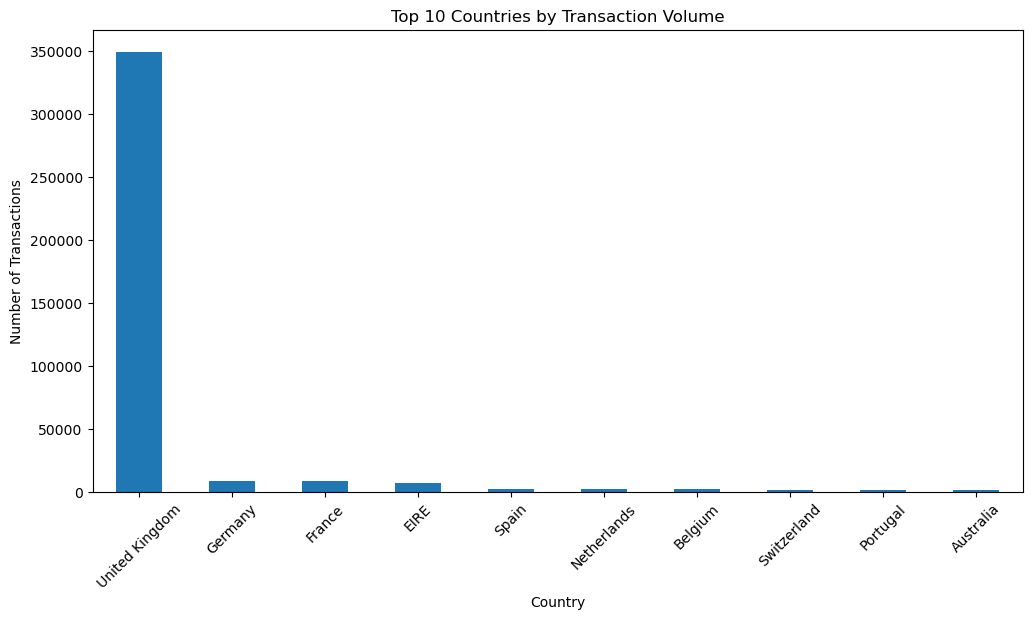

In [12]:

# Exploratory Data Analysis (EDA)

# Transaction Volume by Country

country_transactions = (
    df.groupby('Country')['InvoiceNo']
      .count()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
country_transactions.plot(kind='bar')
plt.title('Top 10 Countries by Transaction Volume')
plt.xlabel('Country')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

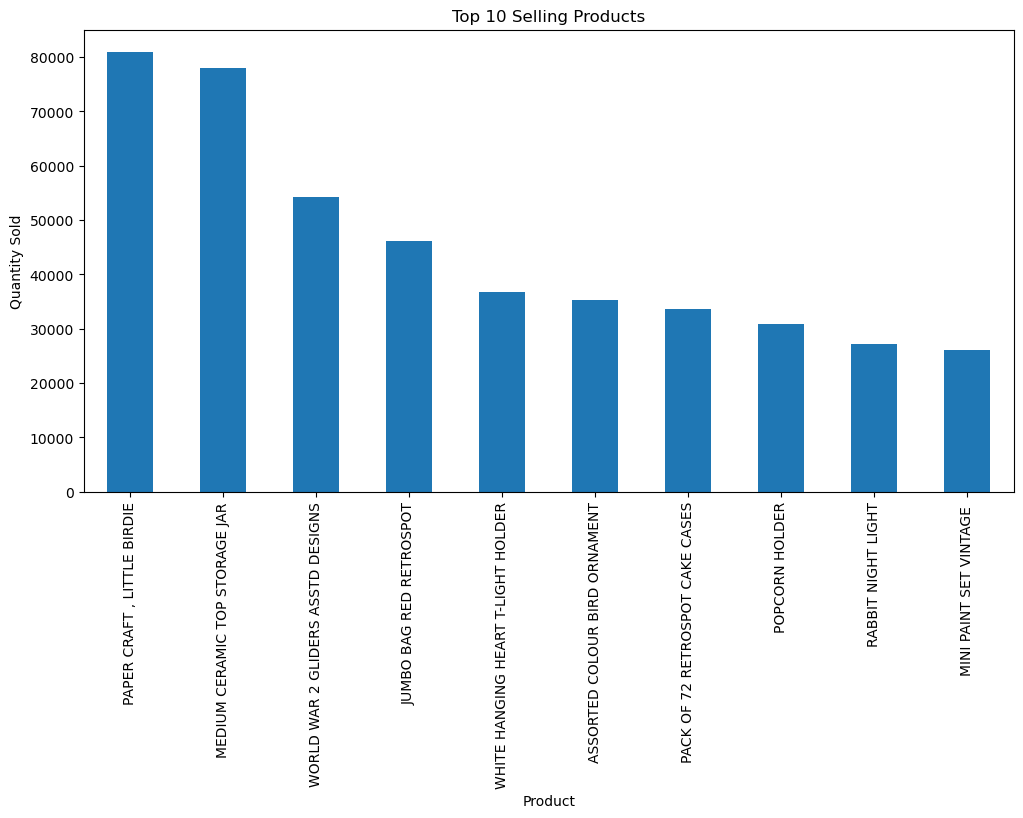

In [13]:

# Top-Selling Products

top_products = (
    df.groupby('Description')['Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar')
plt.title('Top 10 Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=90)
plt.show()

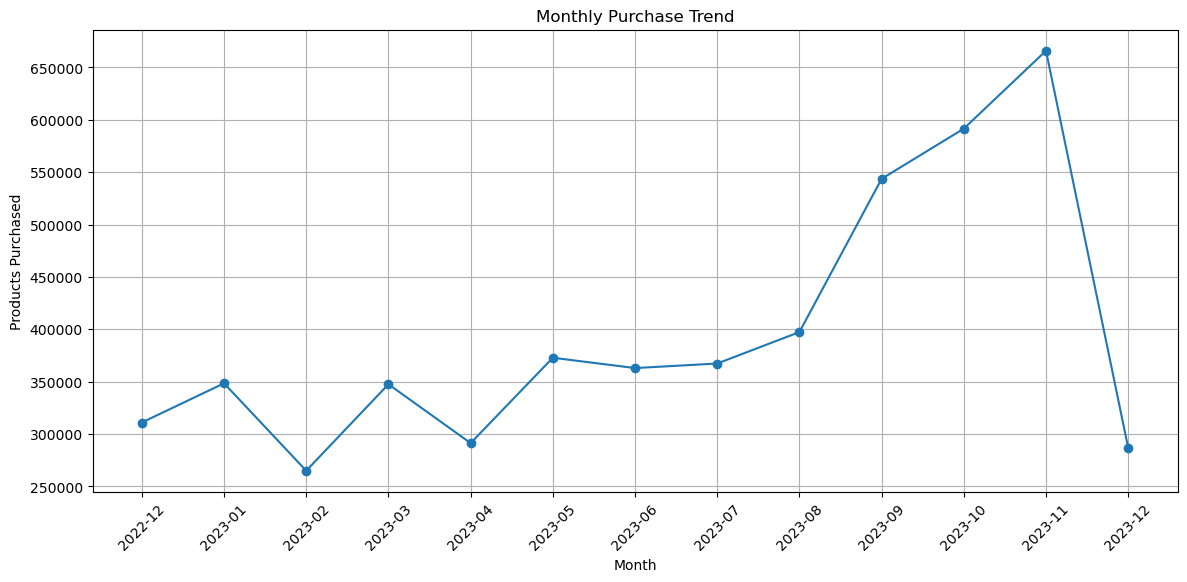

In [14]:
# Purchase Trends Over Time

df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = (
    df.groupby('Month')['Quantity']
      .sum()
      .reset_index()
)

monthly_sales['Month'] = monthly_sales['Month'].astype(str)


# Visualization

plt.figure(figsize=(14,6))
plt.plot(monthly_sales['Month'],
         monthly_sales['Quantity'],
         marker='o')

plt.title('Monthly Purchase Trend')
plt.xlabel('Month')
plt.ylabel('Products Purchased')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

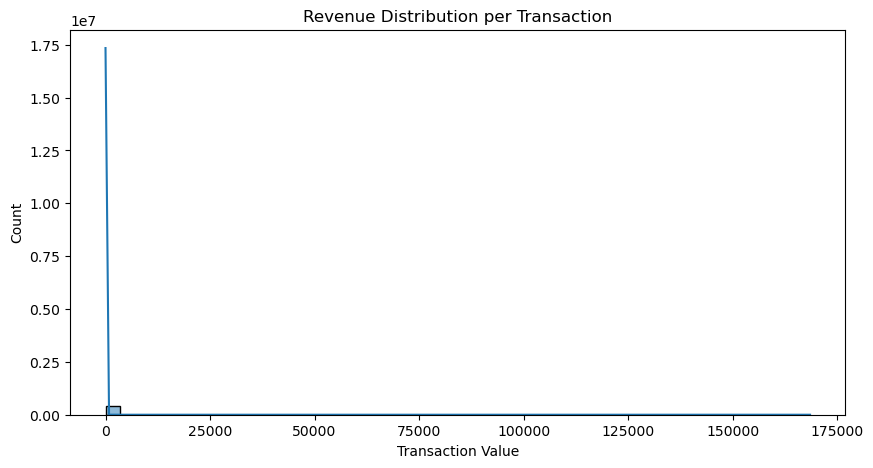

In [15]:
# Monetary Distribution Per Transaction

# Create Transaction Revenue

df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Histogram
plt.figure(figsize=(10,5))
sns.histplot(df['TotalAmount'],
             bins=50,
             kde=True)

plt.title('Revenue Distribution per Transaction')
plt.xlabel('Transaction Value')
plt.show()

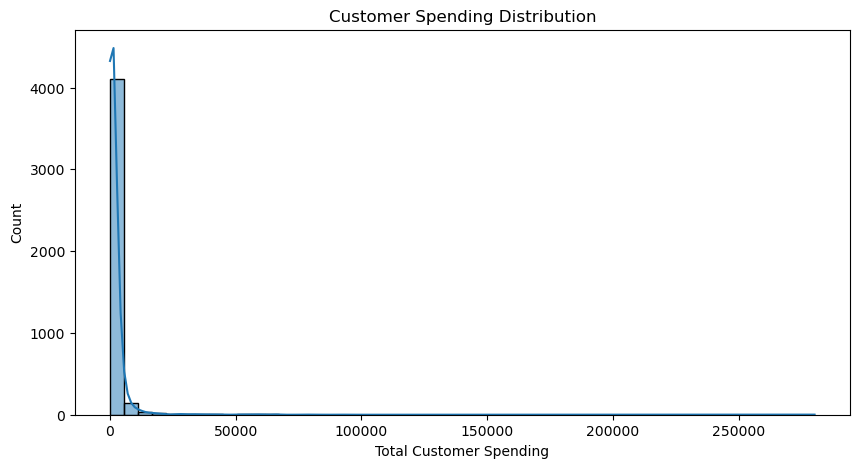

In [16]:

# Monetary Distribution Per Customer
# Customer Revenue

customer_revenue = (
    df.groupby('CustomerID')['TotalAmount']
      .sum()
)

plt.figure(figsize=(10,5))
sns.histplot(customer_revenue,
             bins=50,
             kde=True)

plt.title('Customer Spending Distribution')
plt.xlabel('Total Customer Spending')
plt.show()

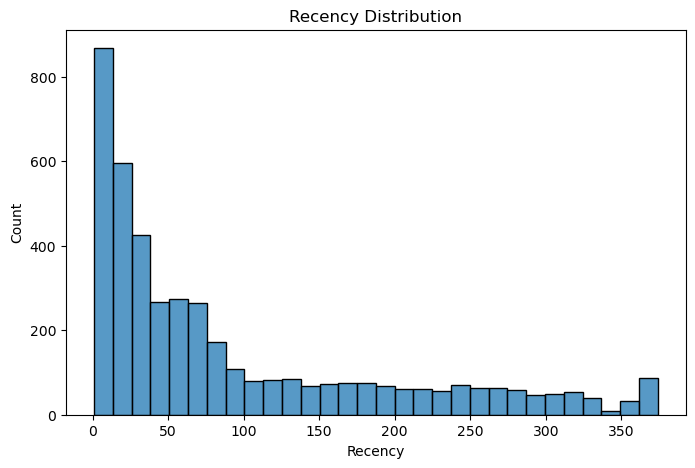

In [17]:
# RFM Analysis
# Calculate RFM Metrics

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

# RFM Distributions
# Recency

plt.figure(figsize=(8,5))
sns.histplot(rfm['Recency'], bins=30)
plt.title('Recency Distribution')
plt.show()

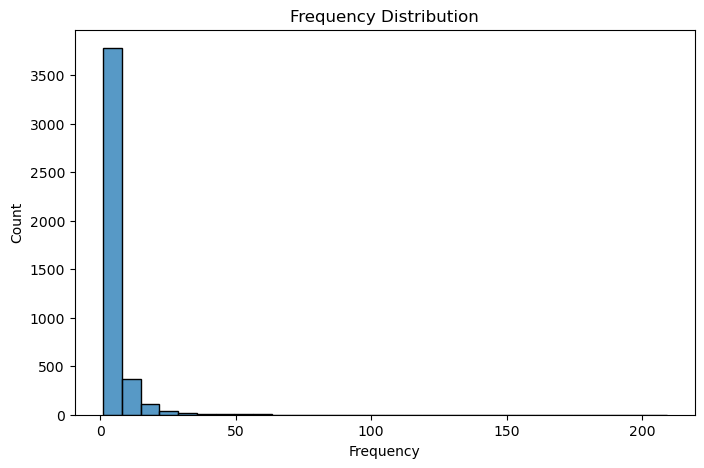

In [18]:
# Frequency

plt.figure(figsize=(8,5))
sns.histplot(rfm['Frequency'], bins=30)
plt.title('Frequency Distribution')
plt.show()

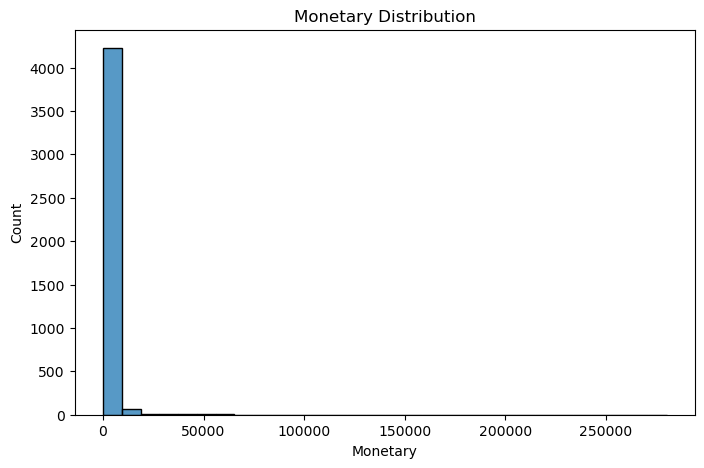

In [19]:
# Monetary

plt.figure(figsize=(8,5))
sns.histplot(rfm['Monetary'], bins=30)
plt.title('Monetary Distribution')
plt.show()

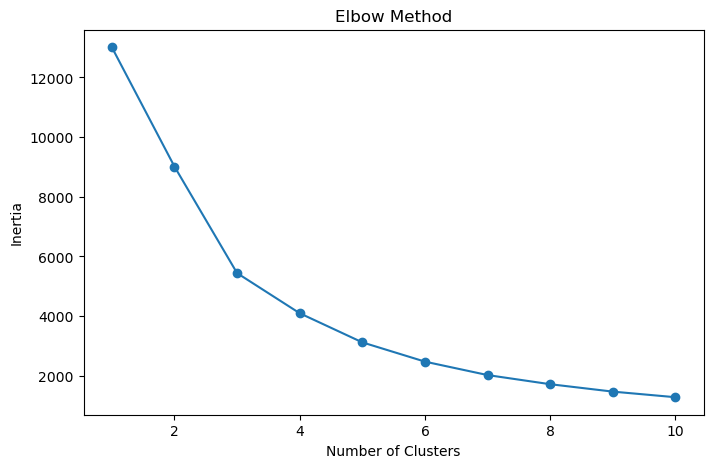

In [20]:
# Elbow Curve for Cluster Selection
# Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Elbow Method

from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

# Plot

plt.figure(figsize=(8,5))
plt.plot(range(1,11),
         inertia,
         marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [21]:
# Customer Cluster Profiles
# Apply K-Means

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
# Cluster Summary
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
})

print(cluster_profile)

            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1353.625312
1        248.075914   1.552015     478.848773
2          7.384615  82.538462  127187.959231
3         15.500000  22.333333   12690.500392


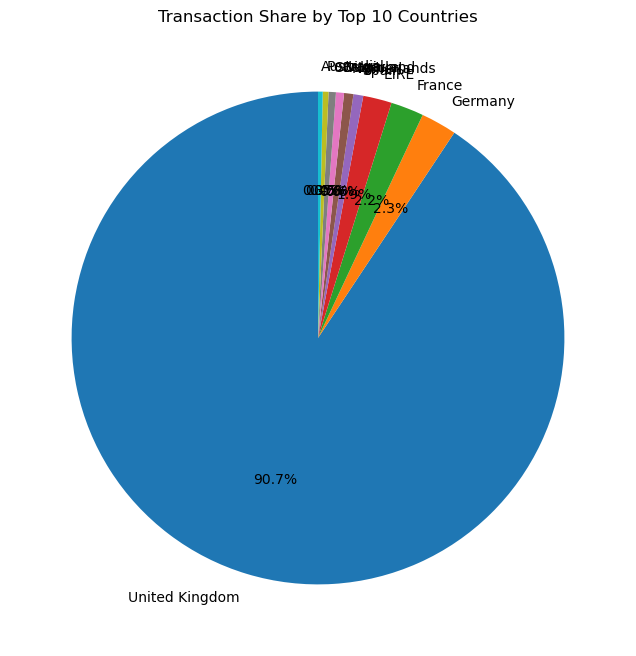

In [22]:

# 1. Pie Chart – Top 10 Countries by Transactions

country_counts = df['Country'].value_counts().head(10)

plt.figure(figsize=(8,8))
plt.pie(
    country_counts,
    labels=country_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Transaction Share by Top 10 Countries')
plt.show()

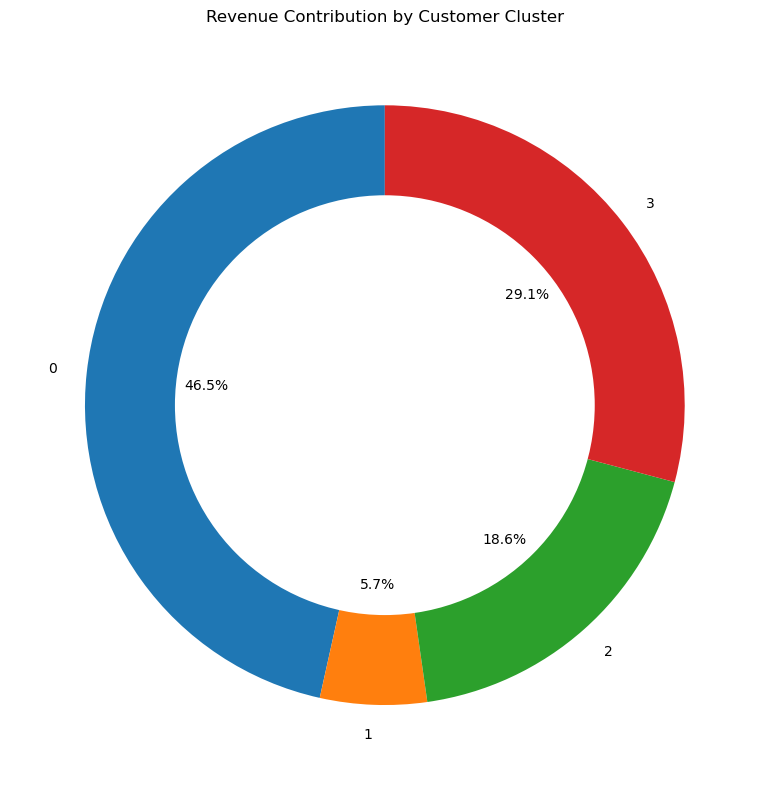

In [23]:
# 2. Donut Chart – Revenue Contribution by Customer Cluster

cluster_revenue = rfm.groupby('Cluster')['Monetary'].sum()

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    cluster_revenue,
    labels=cluster_revenue.index,
    autopct='%1.1f%%',
    startangle=90
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Revenue Contribution by Customer Cluster')
plt.tight_layout()
plt.show()

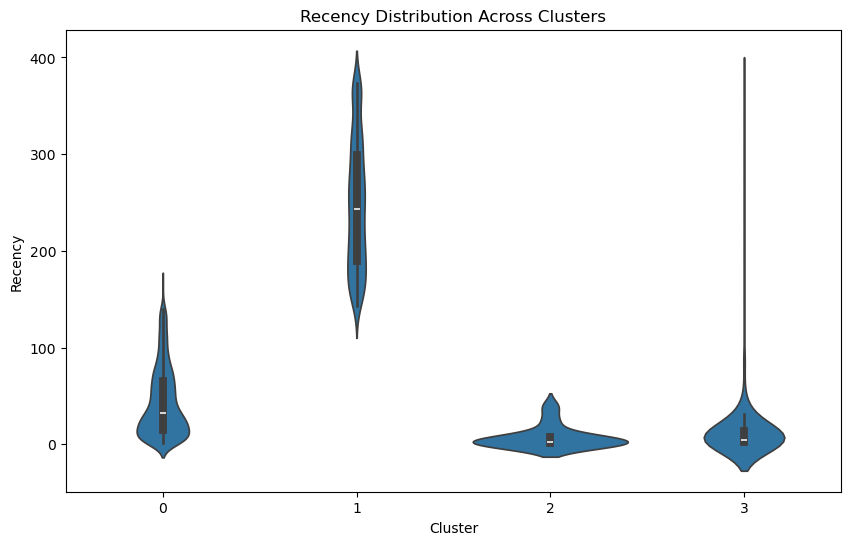

In [24]:
# 3. Violin Plot – Recency by Cluster

plt.figure(figsize=(10,6))

sns.violinplot(
    x='Cluster',
    y='Recency',
    data=rfm
)

plt.title('Recency Distribution Across Clusters')
plt.show()

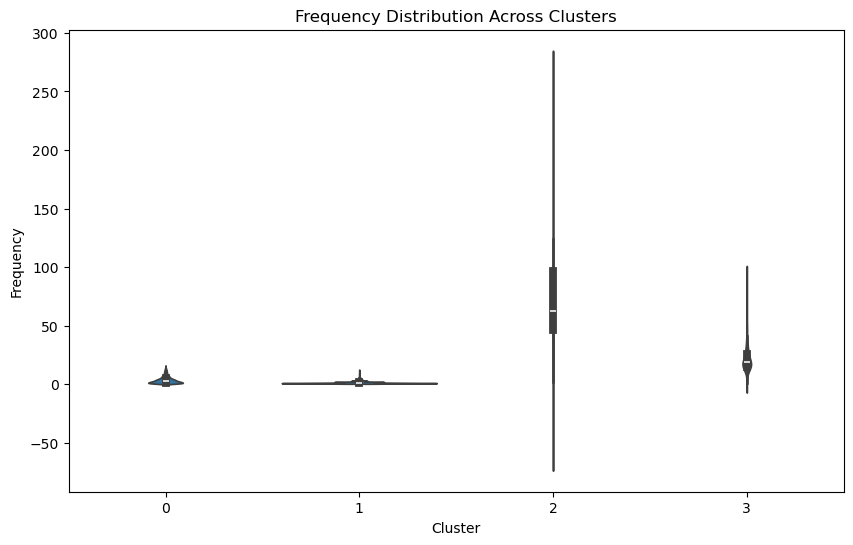

In [25]:
# 4. Violin Plot – Frequency by Cluster

plt.figure(figsize=(10,6))

sns.violinplot(
    x='Cluster',
    y='Frequency',
    data=rfm
)

plt.title('Frequency Distribution Across Clusters')
plt.show()

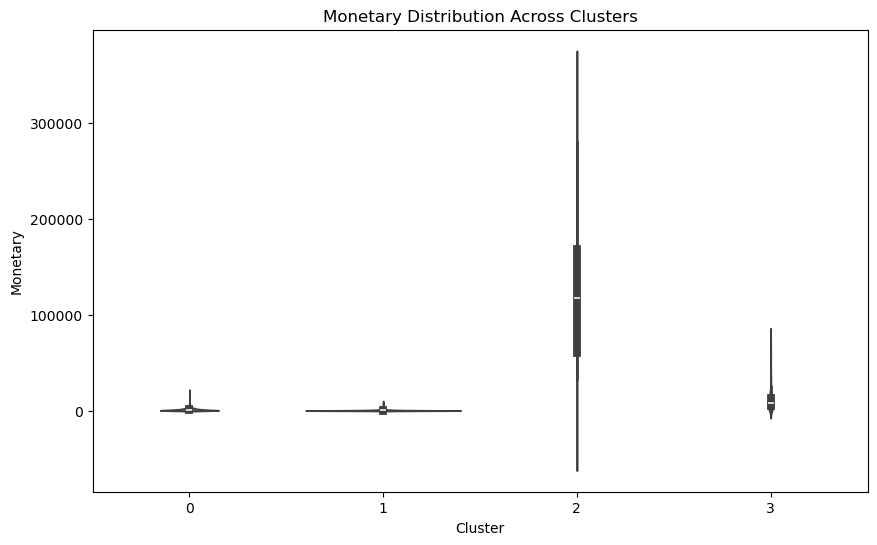

In [26]:
# 5. Violin Plot – Monetary by Cluster

plt.figure(figsize=(10,6))

sns.violinplot(
    x='Cluster',
    y='Monetary',
    data=rfm
)

plt.title('Monetary Distribution Across Clusters')
plt.show()

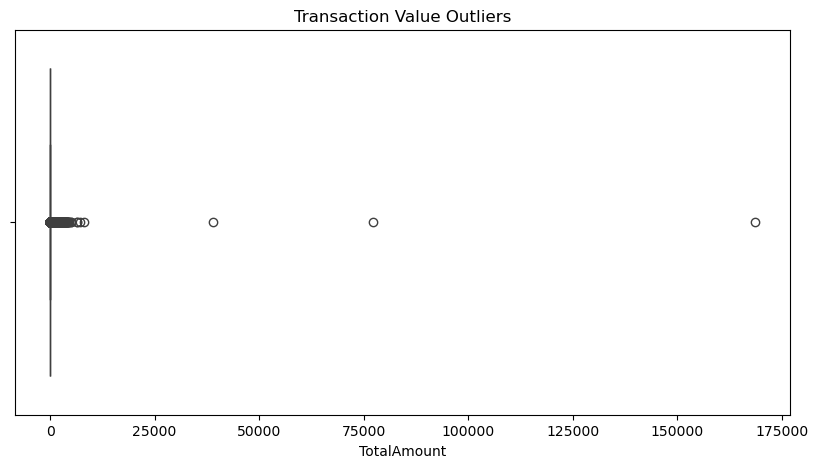

In [27]:
# 6. Box Plot – Transaction Amount Outliers

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['TotalAmount']
)

plt.title('Transaction Value Outliers')
plt.show()

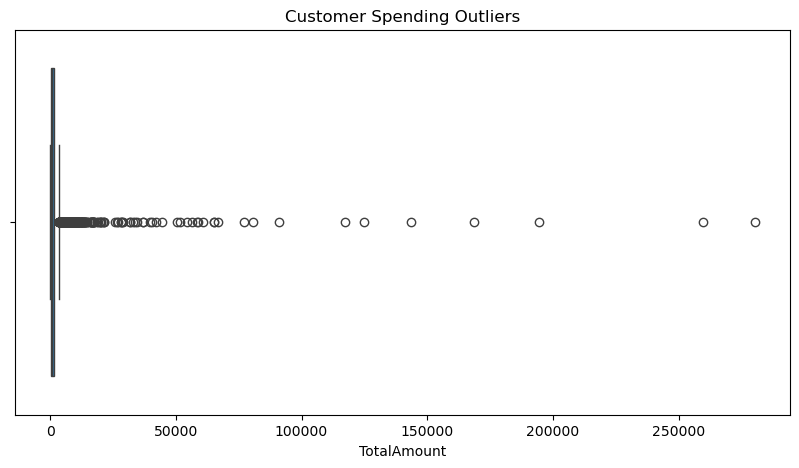

In [28]:
# 7. Box Plot – Customer Spending Outliers

customer_spending = (
    df.groupby('CustomerID')['TotalAmount']
      .sum()
      .reset_index()
)

plt.figure(figsize=(10,5))

sns.boxplot(
    x=customer_spending['TotalAmount']
)

plt.title('Customer Spending Outliers')
plt.show()

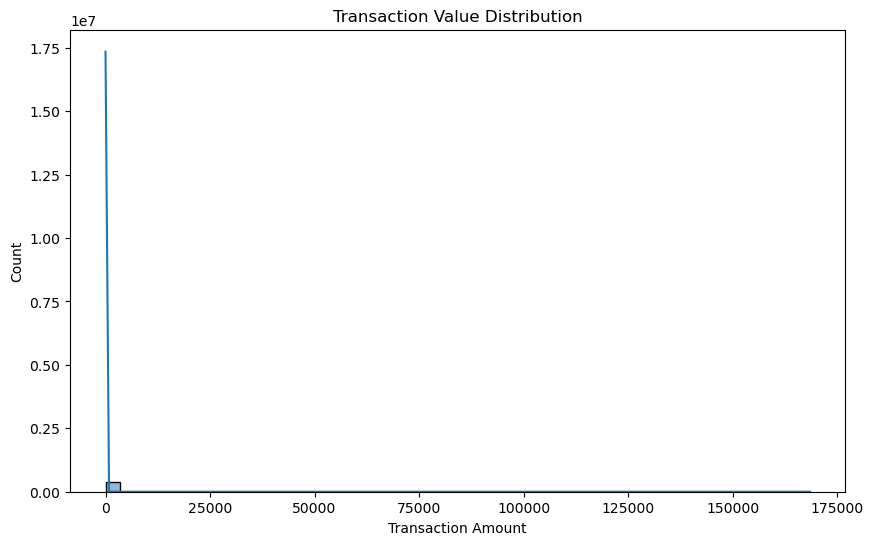

In [29]:

# 8. Histogram + KDE – Transaction Value Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    df['TotalAmount'],
    bins=50,
    kde=True
)

plt.title('Transaction Value Distribution')
plt.xlabel('Transaction Amount')
plt.show()

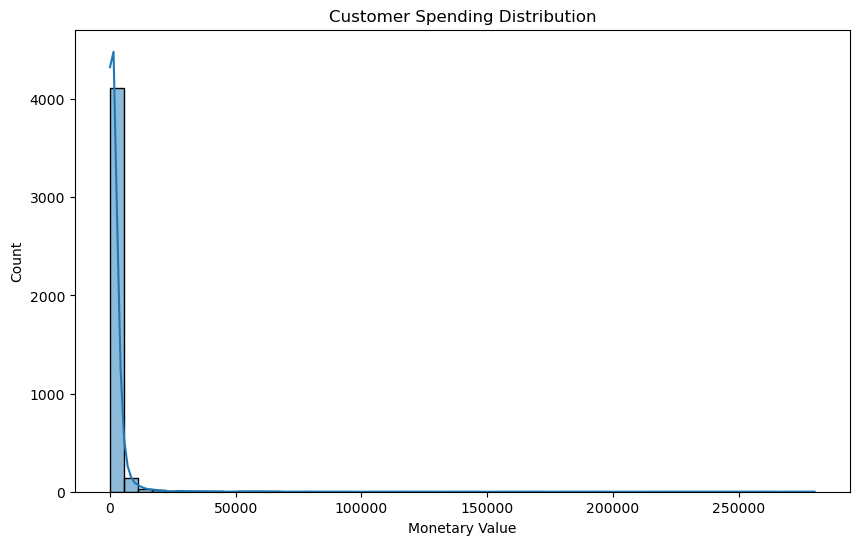

In [30]:
# 9. Histogram + KDE – Customer Spending Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    rfm['Monetary'],
    bins=50,
    kde=True
)

plt.title('Customer Spending Distribution')
plt.xlabel('Monetary Value')
plt.show()

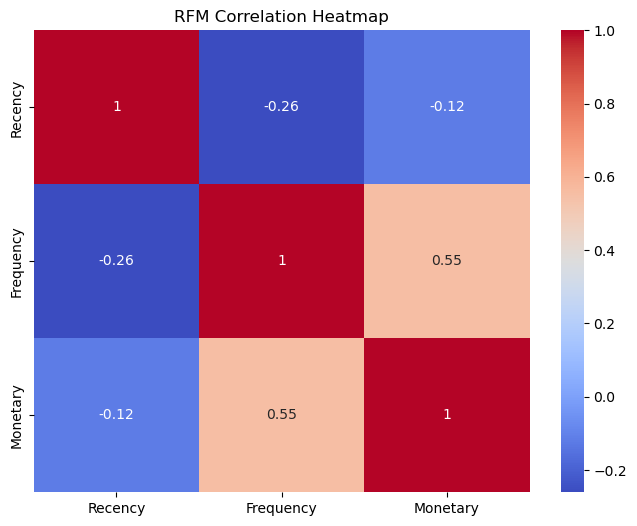

In [31]:

# 10. Correlation Heatmap of RFM Metrics

plt.figure(figsize=(8,6))

sns.heatmap(
    rfm[['Recency','Frequency','Monetary']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('RFM Correlation Heatmap')
plt.show()

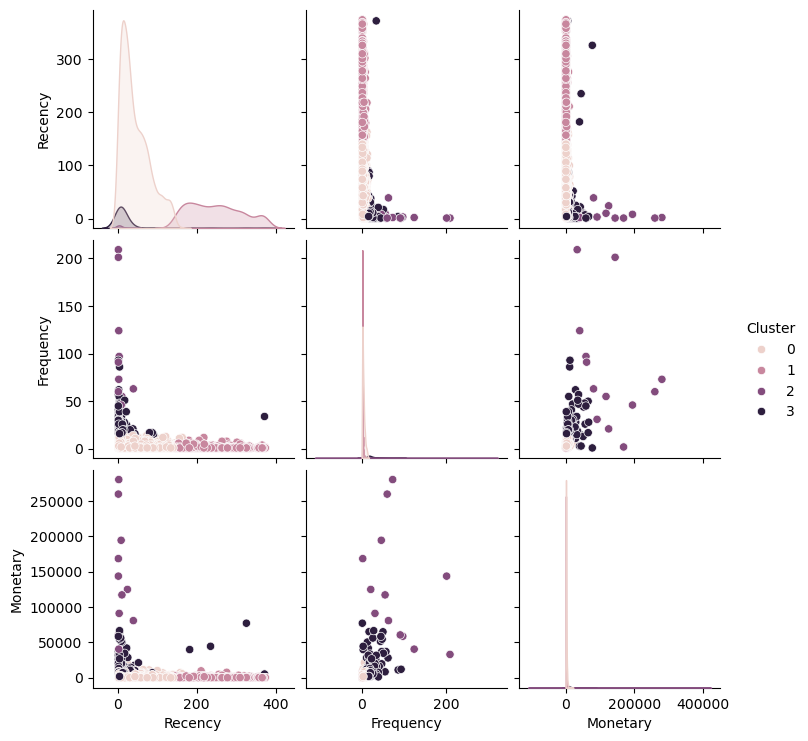

In [32]:
# 11. Pair Plot for Customer Segments

sns.pairplot(
    rfm,
    vars=['Recency','Frequency','Monetary'],
    hue='Cluster'
)

plt.show()

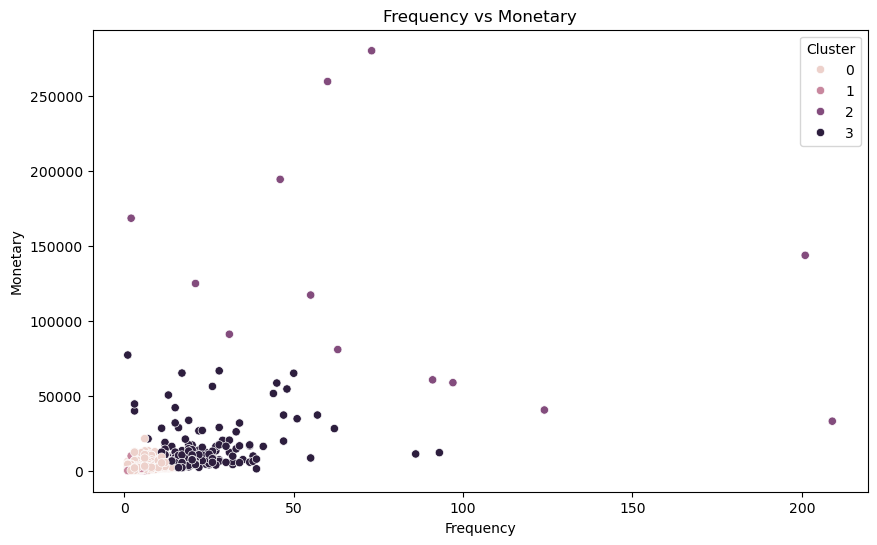

In [33]:

# 12. Scatter Plot – Frequency vs Monetary

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster'
)

plt.title('Frequency vs Monetary')
plt.show()

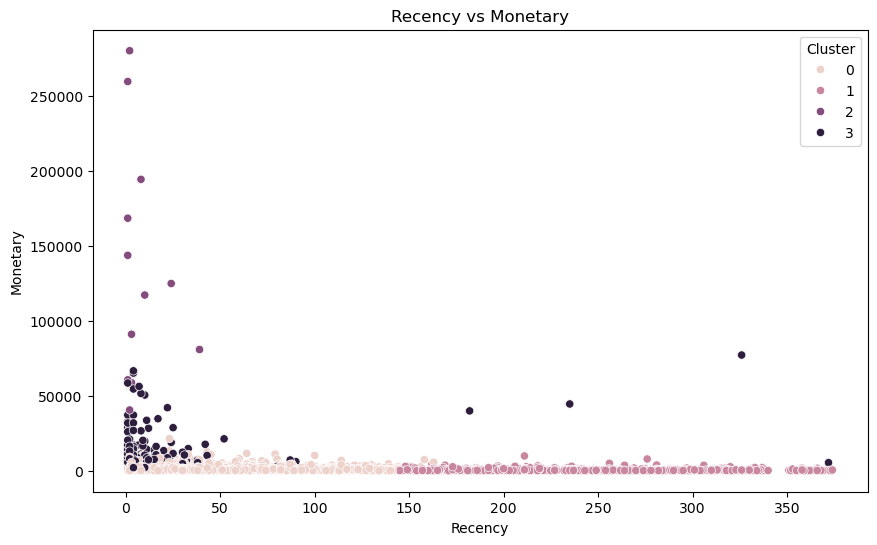

In [34]:

# 13. Scatter Plot – Recency vs Monetary

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster'
)

plt.title('Recency vs Monetary')
plt.show()

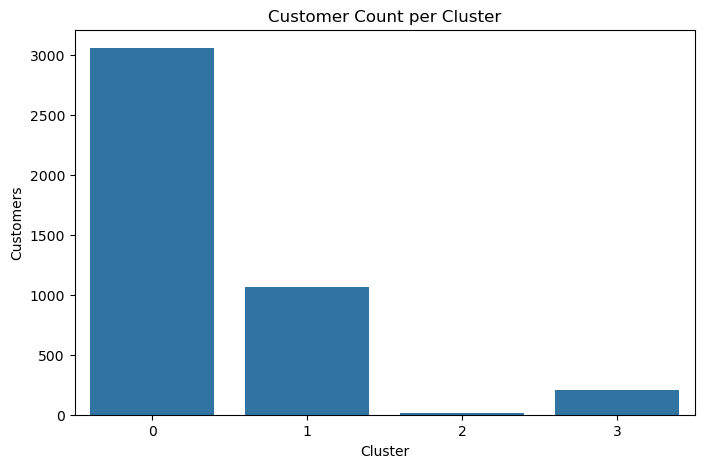

In [35]:

# 14. Customer Cluster Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    x='Cluster',
    data=rfm
)

plt.title('Customer Count per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Customers')
plt.show()

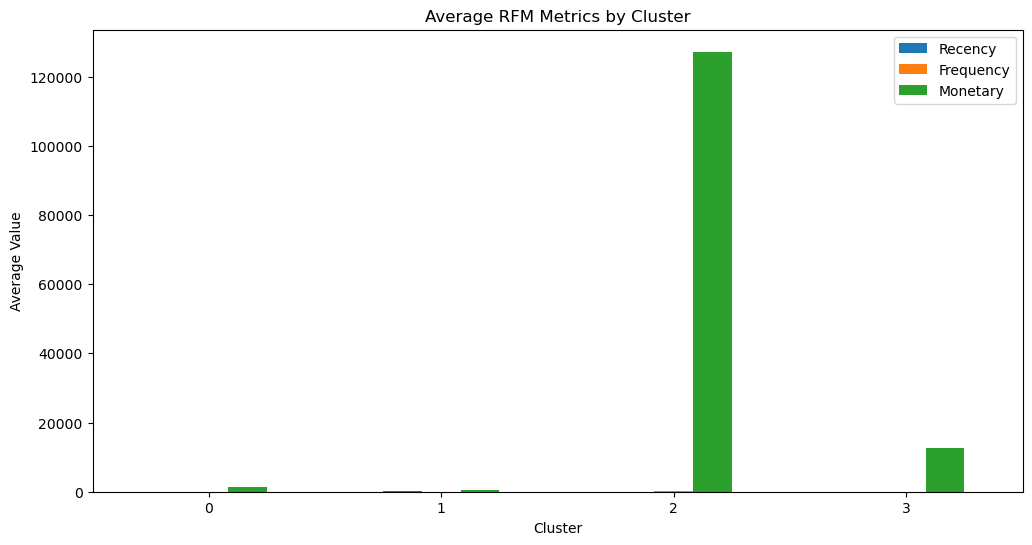

In [36]:
# 15. Average RFM Metrics by Cluster

cluster_profile = (
    rfm.groupby('Cluster')
       .agg({
           'Recency':'mean',
           'Frequency':'mean',
           'Monetary':'mean'
       })
)

cluster_profile.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Average RFM Metrics by Cluster')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.show()

In [37]:

# Product Recommendation Similarity Matrix
# Customer-Product Matrix

customer_product = df.pivot_table(
    index='CustomerID',
    columns='StockCode',
    values='Quantity',
    fill_value=0
)

In [38]:
# Cosine Similarity

from sklearn.metrics.pairwise import cosine_similarity

product_similarity = cosine_similarity(
    customer_product.T
)

In [39]:
# Similarity Matrix

similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product.columns,
    columns=customer_product.columns
)

In [40]:

# 1. Feature Engineering (RFM)

import pandas as pd
import numpy as np

In [41]:

# Create Total Amount
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Reference date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM Calculation
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [42]:

# 2. Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

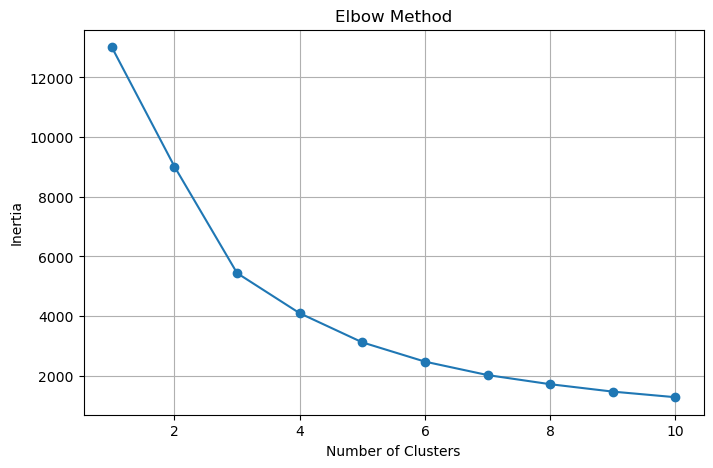

In [43]:
# 3. Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)

plt.show()

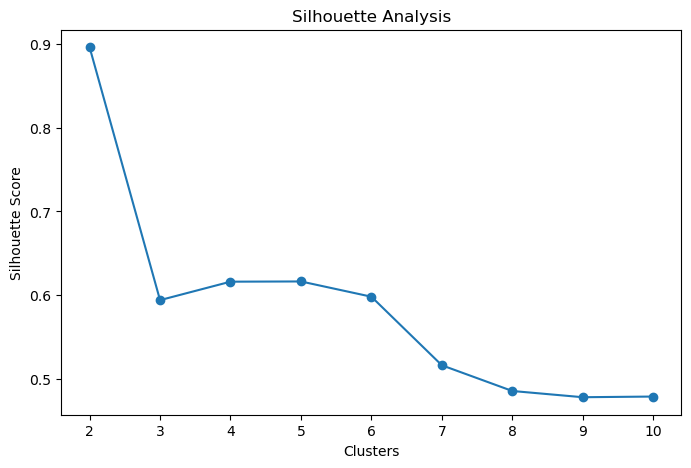

Best Cluster Count: 2


In [44]:
# 4. Silhouette Score

from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.xlabel("Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

best_k = scores.index(max(scores)) + 2

print("Best Cluster Count:", best_k)

In [45]:

# 5. Train Final KMeans

best_k = 4

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [46]:

# 6. Cluster Profiling

cluster_profile = rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

print(cluster_profile)

         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1353.63
1         248.08       1.55     478.85
2           7.38      82.54  127187.96
3          15.50      22.33   12690.50


In [47]:

# 7. Assign Business Labels

cluster_profile = cluster_profile.sort_values(
    by='Monetary',
    ascending=False
)

segment_names = {
    cluster_profile.index[0]: 'High-Value',
    cluster_profile.index[1]: 'Regular',
    cluster_profile.index[2]: 'Occasional',
    cluster_profile.index[3]: 'At-Risk'
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)

print(
    rfm[['Cluster','Segment']].head()
)

            Cluster     Segment
CustomerID                     
12346.0           3     Regular
12347.0           0  Occasional
12348.0           0  Occasional
12349.0           0  Occasional
12350.0           1     At-Risk


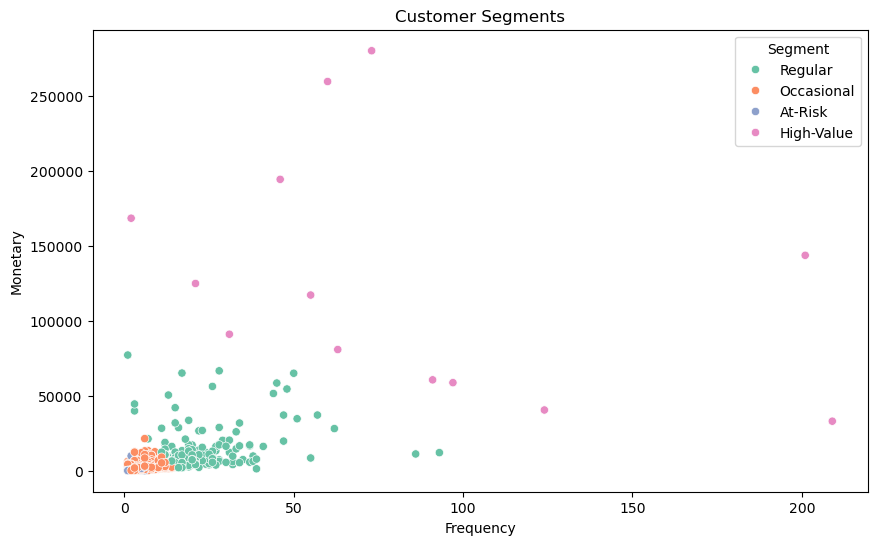

In [48]:

# 8. 2D Cluster Visualization

import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    palette='Set2'
)

plt.title(
    "Customer Segments"
)

plt.show()

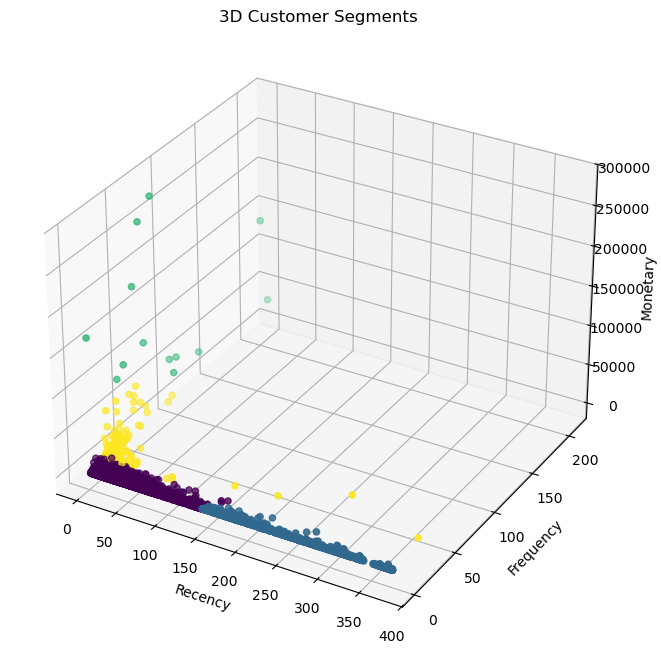

In [49]:

# 9. 3D Cluster Visualization

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)

scatter = ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis'
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

plt.title(
    '3D Customer Segments'
)

plt.show()

In [50]:
# 10. Save KMeans Model

import joblib

joblib.dump(
    kmeans,
    'models/kmeans_model.pkl'
)

joblib.dump(
    scaler,
    'models/rfm_scaler.pkl'
)

print("Models Saved Successfully")

Models Saved Successfully


In [51]:
# Recommendation System
# 11. Create Customer-Product Matrix

customer_product = pd.pivot_table(
    df,
    index='CustomerID',
    columns='Description',
    values='Quantity',
    fill_value=0
)

In [52]:

# 12. Product Similarity Matrix

from sklearn.metrics.pairwise import cosine_similarity

product_similarity = cosine_similarity(
    customer_product.T
)

similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product.columns,
    columns=customer_product.columns
)

In [53]:

# 13. Save Similarity Matrix

joblib.dump(
    similarity_df,
    'models/product_similarity.pkl'
)

['models/product_similarity.pkl']

In [54]:

# 14. Recommendation Function

def recommend_products(
    product_name,
    similarity_df,
    top_n=5
):

    if product_name not in similarity_df.columns:

        return ["Product Not Found"]

    recommendations = (
        similarity_df[product_name]
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
    )

    return recommendations.index.tolist()

In [55]:

# 15. Test Recommendation

product_name = "WHITE HANGING HEART T-LIGHT HOLDER"

recommendations = recommend_products(
    product_name,
    similarity_df
)

print("\nRecommended Products:\n")

for product in recommendations:
    print(product)



Recommended Products:

GIN + TONIC DIET METAL SIGN
TEA TIME TEA TOWELS 
FAIRY CAKE FLANNEL ASSORTED COLOUR
DOORMAT FAIRY CAKE
RED HANGING HEART T-LIGHT HOLDER
